# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [5]:
#Library untuk manipulasi data
import pandas as pd
import numpy as np

#Library untuk Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#Library untuk preprocessing dan machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [6]:
#Memuat file dataset dalam daraframe
test = pd.read_csv("/content/Medical_insurance.csv")
test.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# Cek jumlah data
jumlah_data = test.shape[0]
print(f'Jumlah data dalam dataset: {jumlah_data}')

Jumlah data dalam dataset: 2772


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [8]:
# Memastikan dataset terbaca dengan benar
print("Tampilan Awal Dataset: ")
print(test.head())

Tampilan Awal Dataset: 
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [9]:
# Memastikan informasi dataset
print("Informasi Dataset:")
print(test.info())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None


In [10]:
# 1. Memahami Struktur Data
print("Jumlah Baris dan Kolom dalam Dataset:")
print(test.shape)
print("Jenis Data Setiap Kolom:")
print(test.dtypes)

Jumlah Baris dan Kolom dalam Dataset:
(2772, 7)
Jenis Data Setiap Kolom:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [11]:
# 2. Menangani Data yang Hilang
print("Data yang Hilang pada Setiap Kolom: ")
missing_values = test.isnull().sum()
print(missing_values)

Data yang Hilang pada Setiap Kolom: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [12]:
# Mengisi nilai yang hilang pada kolom numerikal dengan mean
for column in test.select_dtypes(include=['float64', 'int64']).columns:
    if missing_values[column] > 0:
        test.loc[:, column] = test[column].fillna(test[column].mean())

In [13]:
# Mengisi nilai yang hilang pada kolomkategorikal dengan modus
for column in test.select_dtypes(include=['object']).columns:
    if missing_values[column] > 0:
        test.loc[:, column] = test[column].fillna(test[column].mode()[0])

In [14]:
# 3. Analisis Distribusi dan Korelasi
# statistika Deskriptif
print("Statistika Deskriptif:")
print(test.describe())

Statistika Deskriptif:
               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010


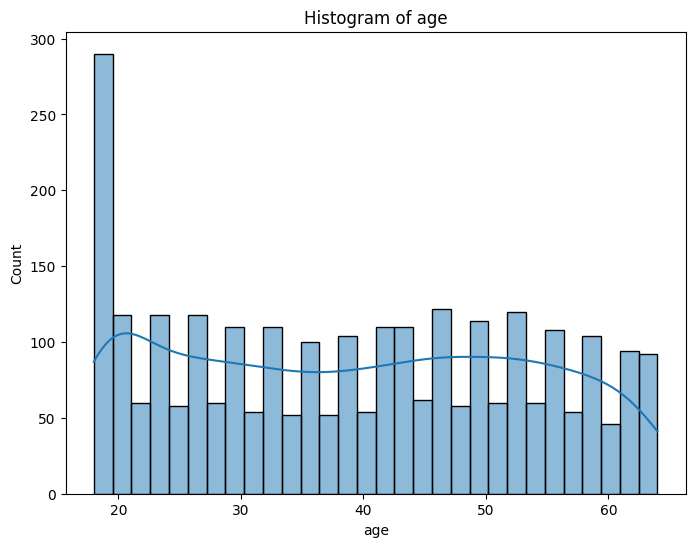

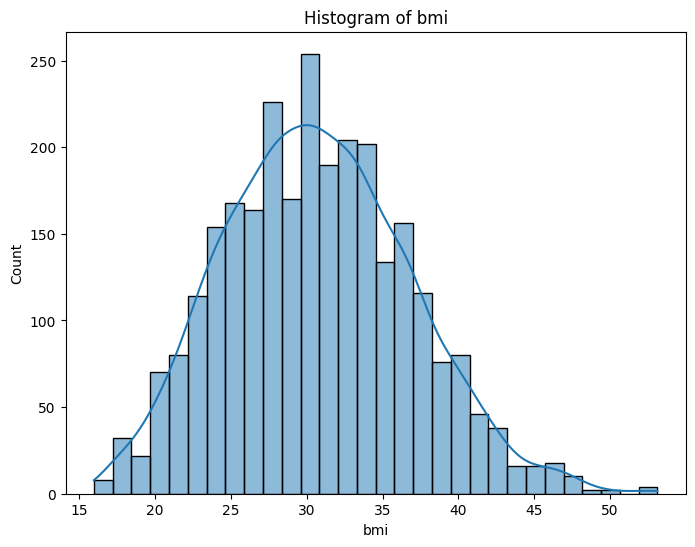

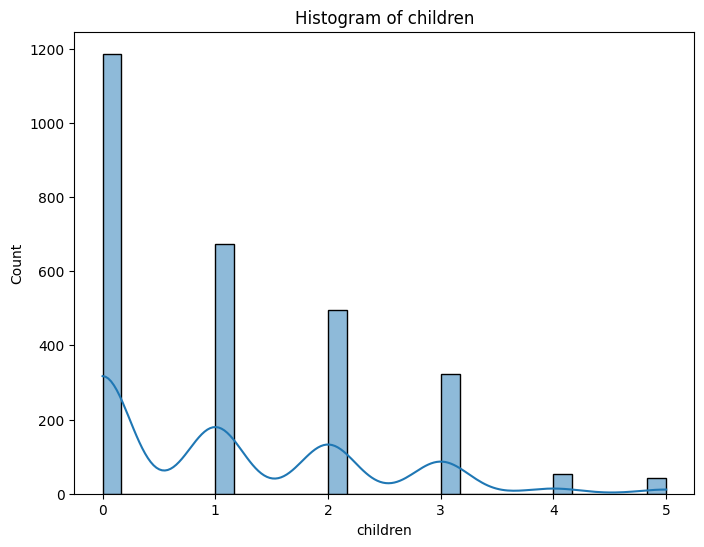

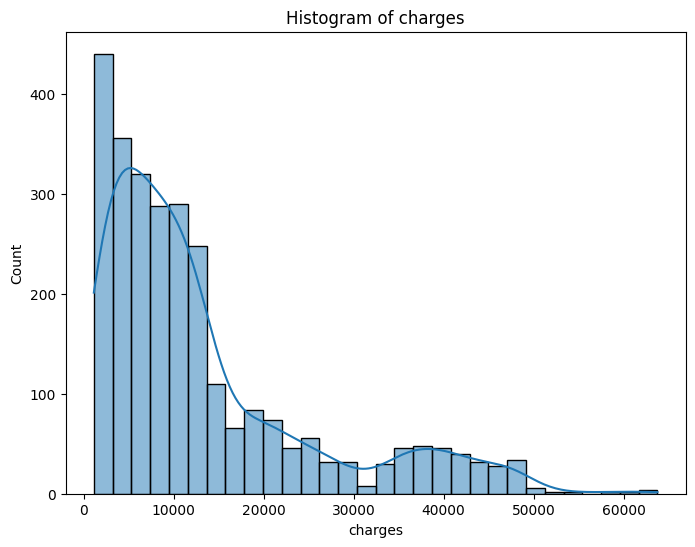

In [15]:
# Melakukan Visualisasi Distribusi Numerikal ( histogram )
numeric_columns = test.select_dtypes(include=['float64', 'int64']).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(test[column], bins=30, kde=True)
    plt.title(f'Histogram of {column}')

In [16]:
# Matriks Kolerasi
#Filter kolomnumerik
numeric_columns = test.select_dtypes(include=['float64', 'int64']).columns

In [17]:
# Hapus kolom yang seluruh nilainya NaN
valid_numeric_columns = test[numeric_columns].dropna(axis=1, how='all').columns


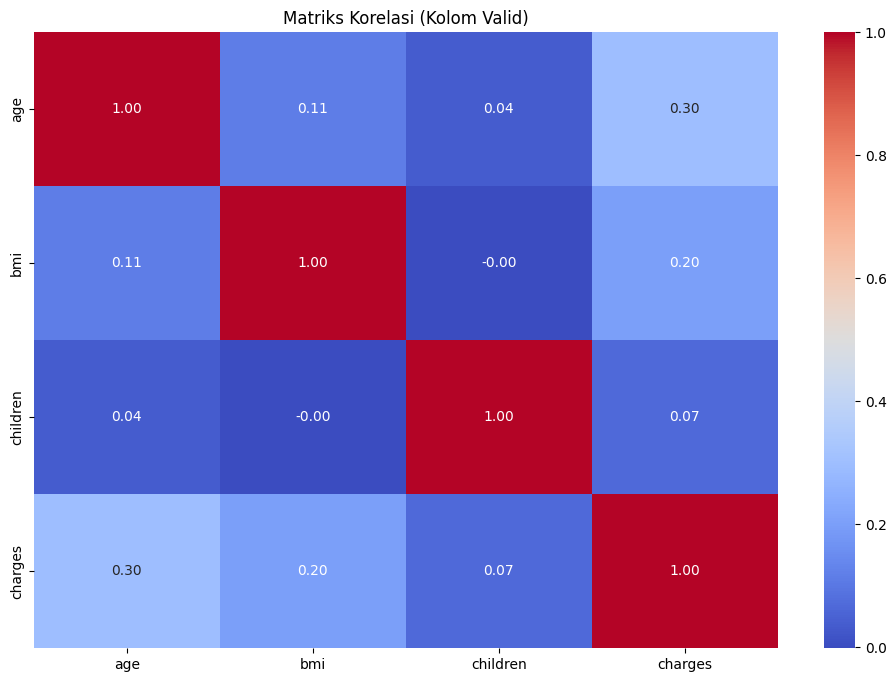

In [18]:
# Hapus kolom dengan variansi nol
valid_numeric_columns = [
    col for col in valid_numeric_columns if test[col].nunique() > 1
]

if valid_numeric_columns:  # Cek jika ada kolom valid yang tersisa
    # Hitung matriks korelasi hanya pada kolom valid
    correlation_matrix = test[valid_numeric_columns].corr()

    # Plot heatmap matriks korelasi
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title("Matriks Korelasi (Kolom Valid)")
    plt.show()
else:
    print("Tidak ada kolom numerikal valid untuk menghitung korelasi.")



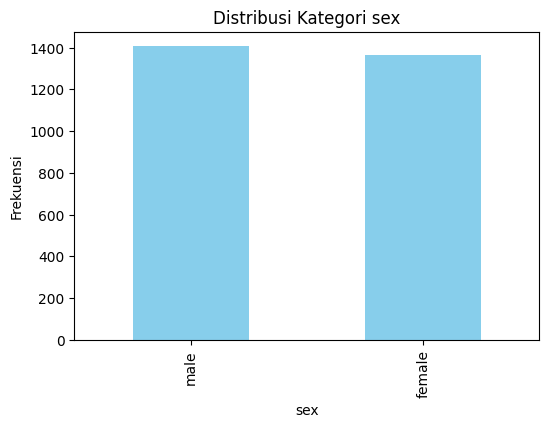

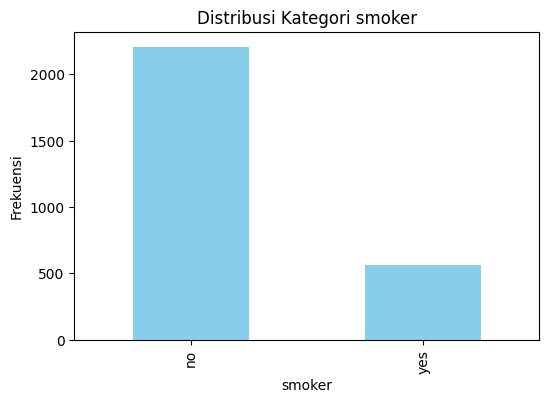

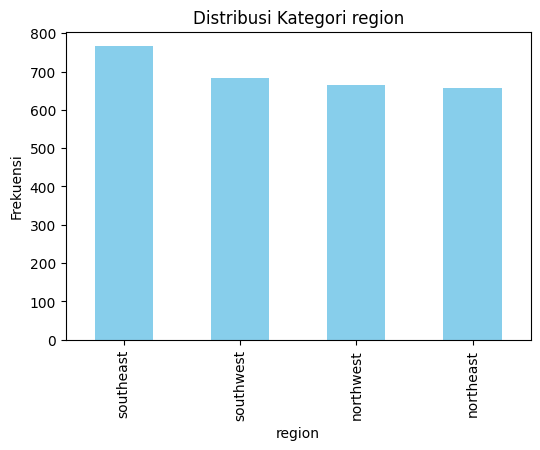

In [19]:
# 4. Visualisasi Data Kategorikal
max_unique_values = 20  # Maksimal jumlah kategori yang divisualisasikan
categorical_cols = test.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unique_values = test[col].nunique()
    if unique_values > max_unique_values:
        print(f"\nKolom `{col}` memiliki terlalu banyak kategori ({unique_values}). Menampilkan hanya {max_unique_values} teratas.")
        top_categories = test[col].value_counts().nlargest(max_unique_values)
        plt.figure(figsize=(6, 4))
        top_categories.plot(kind='bar', color='skyblue')
        plt.title(f"Distribusi Kategori (Top {max_unique_values}) {col}")
        plt.xlabel(col)
        plt.ylabel("Frekuensi")
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        test[col].value_counts().plot(kind='bar', color='skyblue')
        plt.title(f"Distribusi Kategori {col}")
        plt.xlabel(col)
        plt.ylabel("Frekuensi")
        plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [20]:
# 1. Menghapus atau Menangani Data Kosong (Sudah ditangani sebelumnya)
print("Jumlah Nilai Kosong Setelah Penanganan:")
print(test.isnull().sum())

Jumlah Nilai Kosong Setelah Penanganan:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [21]:
# 2. Menghapus Data Duplikasi
print("\nJumlah Baris Sebelum Menghapus Duplikasi:", test.shape[0])
test.drop_duplicates(inplace=True)
print("Jumlah Baris Setelah Menghapus Duplikasi:", test.shape[0])


Jumlah Baris Sebelum Menghapus Duplikasi: 2772
Jumlah Baris Setelah Menghapus Duplikasi: 1337


In [22]:
# 3. Normalisasi atau Standarisasi Fitur
numerical_cols = test.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
test[numerical_cols] = scaler.fit_transform(test[numerical_cols])
print("\nData Numerikal Setelah Normalisasi/Standarisasi:")
print(test[numerical_cols].head())


Data Numerikal Setelah Normalisasi/Standarisasi:
        age       bmi  children   charges
0 -1.440418 -0.453160 -0.909234  0.297857
1 -1.511647  0.509422 -0.079442 -0.954381
2 -0.799350  0.383155  1.580143 -0.729373
3 -0.443201 -1.305052 -0.909234  0.719104
4 -0.514431 -0.292456 -0.909234 -0.777499


In [23]:
# 4. Deteksi dan Penanganan Outlier
# Menggunakan metode IQR (Interquartile Range)
Q1 = test[numerical_cols].quantile(0.25)
Q3 = test[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((test[numerical_cols] < (Q1 - 1.5 * IQR)) | (test[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("\nJumlah Outlier Teridentifikasi:", outliers.sum())
# Menghapus outlier jika diperlukan
test = test.loc[~outliers]
print("Jumlah Baris Setelah Menghapus Outlier:", test.shape[0])


Jumlah Outlier Teridentifikasi: 145
Jumlah Baris Setelah Menghapus Outlier: 1192


In [24]:
# 5. Encoding Data Kategorikal
categorical_cols = test.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    test.loc[:, col] = le.fit_transform(test[col])
    label_encoders[col] = le  # Simpan encoder untuk interpretasi nanti
print("\nData Kategorikal Setelah Encoding:")
print(test[categorical_cols].head())


Data Kategorikal Setelah Encoding:
  sex smoker region
0   0      1      3
1   1      0      2
2   1      0      2
3   1      0      1
4   1      0      1


In [25]:
# 6. Binning (Pengelompokan Data)
# Contoh binning untuk kolom 'age'
test['age_binned'] = pd.cut(test['age'], bins=5, labels=False) #membagi kolom age menjadi 5 kelompok
print("\nData setelah binning kolom age:")
print(test[['age', 'age_binned']].head())

# Contoh binning untuk kolom 'bmi' dengan batas kustom
bins_bmi = [0, 18.5, 25, 30, float('inf')]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
test['bmi_binned'] = pd.cut(test['bmi'], bins=bins_bmi, labels=labels_bmi, right=False)
print("\nData setelah binning kolom bmi:")
print(test[['bmi', 'bmi_binned']].head())



Data setelah binning kolom age:
        age  age_binned
0 -1.440418           0
1 -1.511647           0
2 -0.799350           1
3 -0.443201           1
4 -0.514431           1

Data setelah binning kolom bmi:
        bmi   bmi_binned
0 -0.453160          NaN
1  0.509422  Underweight
2  0.383155  Underweight
3 -1.305052          NaN
4 -0.292456          NaN


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [26]:
# Pilih jumlah cluster awal (misalnya, 3)
n_clusters = 3

# Pilih kolom numerikal untuk clustering
numerical_cols = test.select_dtypes(include=['float64', 'int64']).columns
clustering_data = test[numerical_cols]

# Latih model clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

In [27]:
# Elbow Method untuk menentukan jumlah cluster optimal
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)

In [28]:
# Variabel untuk menyimpan label klaster yang valid
valid_cluster_labels = []

for n_clusters in range_n_clusters:
    # Melakukan klasterisasi KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(clustering_data)

    # Menghitung Silhouette Score untuk hasil klasterisasi
    silhouette_avg = silhouette_score(clustering_data, cluster_labels)

    # Simpan inertia (SSE) untuk Elbow Method
    inertia.append(kmeans.inertia_)

    # Hitung silhouette score
    score = silhouette_score(clustering_data, cluster_labels)
    silhouette_scores.append(score)

    # Jika Silhouette Score >= 0.55, simpan label klaster
    if silhouette_avg >= 0.55:
        valid_cluster_labels.append(cluster_labels)
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg} - Disimpan")
    else:
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg} - Tidak Disimpan")


Jumlah klaster: 2, Silhouette Score: 0.3946915619684615 - Tidak Disimpan
Jumlah klaster: 3, Silhouette Score: 0.2988125774686368 - Tidak Disimpan
Jumlah klaster: 4, Silhouette Score: 0.243568533997927 - Tidak Disimpan
Jumlah klaster: 5, Silhouette Score: 0.28320806827711903 - Tidak Disimpan
Jumlah klaster: 6, Silhouette Score: 0.26144385406369475 - Tidak Disimpan
Jumlah klaster: 7, Silhouette Score: 0.24220068063794448 - Tidak Disimpan
Jumlah klaster: 8, Silhouette Score: 0.2630717582989328 - Tidak Disimpan
Jumlah klaster: 9, Silhouette Score: 0.2581896865179497 - Tidak Disimpan
Jumlah klaster: 10, Silhouette Score: 0.2603273176900124 - Tidak Disimpan


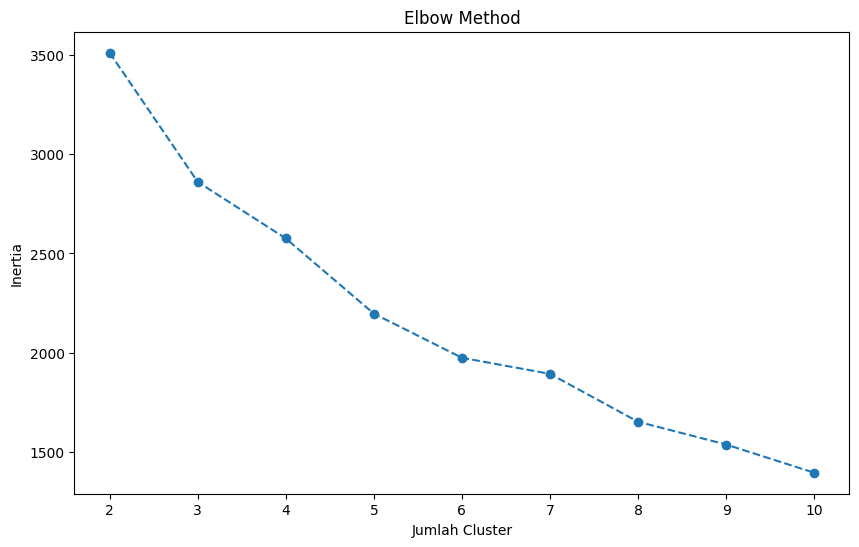

In [29]:
# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.show()

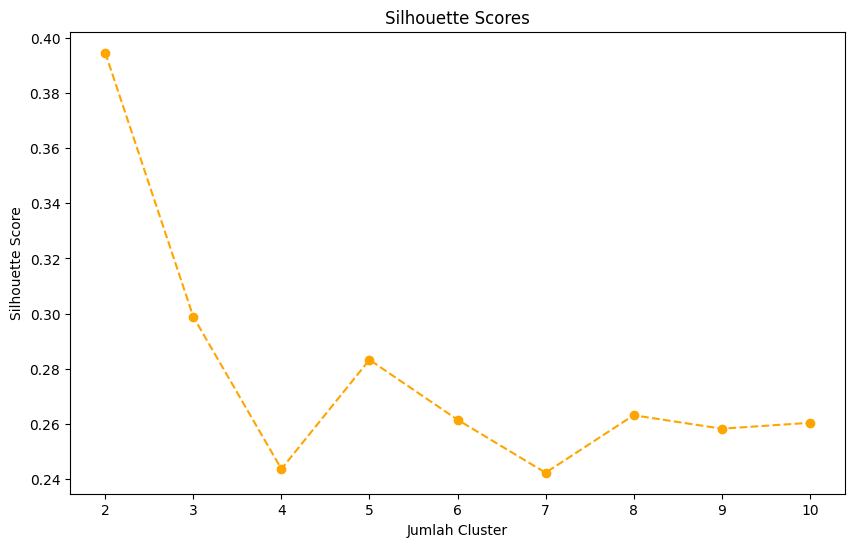

In [30]:
# Plot Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='orange')
plt.title('Silhouette Scores')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.show()

In [31]:
# Pilih jumlah cluster optimal berdasarkan evaluasi
optimal_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 karena range dimulai dari 2
print(f"\nJumlah cluster optimal berdasarkan Silhouette Score: {optimal_n_clusters}")


Jumlah cluster optimal berdasarkan Silhouette Score: 2


In [32]:
# Menghitung silhoutte score
silhouette_score_original = silhouette_scores[0]  # Score awal dengan seluruh fitur
print(f"Silhouette Score Tanpa Feature Selection: {silhouette_score_original}")

Silhouette Score Tanpa Feature Selection: 0.3946915619684615


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

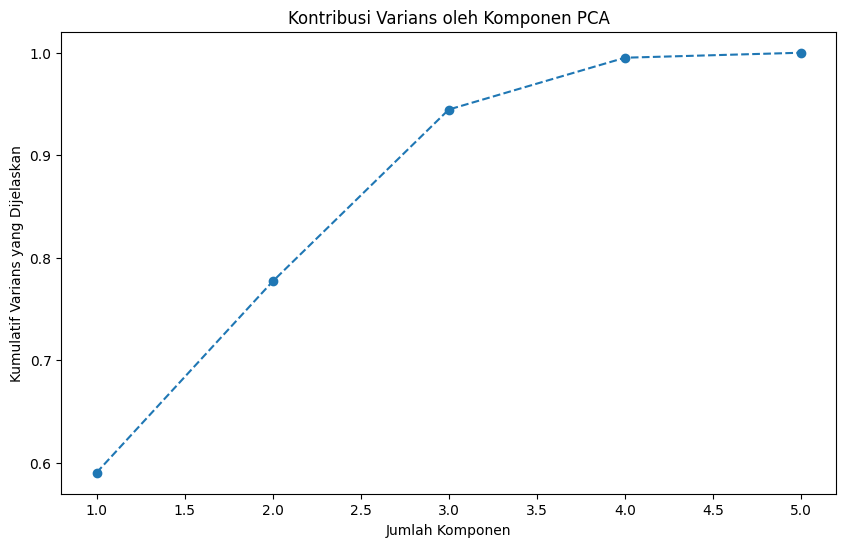

In [33]:
# Lakukan PCA untuk memahami kontribusi fitur
pca = PCA(n_components=len(numerical_cols))
pca_data = pca.fit_transform(clustering_data)

# Plot kontribusi varians setiap komponen
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(numerical_cols)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Kontribusi Varians oleh Komponen PCA')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Varians yang Dijelaskan')
plt.show()

In [34]:
# Standarisasi data
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

# Fit PCA pada data yang sudah distandarisasi
pca = PCA()
pca.fit(clustering_data_scaled)

# Tentukan jumlah komponen yang menjelaskan 50% varians
n_components_optimal = sum(pca.explained_variance_ratio_.cumsum() <= 0.50)
print(f"\nJumlah fitur optimal berdasarkan PCA: {n_components_optimal}")

# Transformasi data berdasarkan fitur utama
reduced_data = PCA(n_components=n_components_optimal).fit_transform(clustering_data_scaled)



Jumlah fitur optimal berdasarkan PCA: 1


In [35]:
# Model clustering baru dengan data hasil reduksi dimensi
kmeans_reduced = KMeans(n_clusters=2, random_state=42)
cluster_labels_reduced = kmeans_reduced.fit_predict(reduced_data)

# Hitung Silhouette Score untuk data hasil feature selection
silhouette_score_reduced = silhouette_score(reduced_data, cluster_labels_reduced)
print(f"\nSilhouette Score dengan Feature Selection: {silhouette_score_reduced}")

# Bandingkan dengan Silhouette Score sebelumnya
silhouette_score_original = silhouette_scores[0]  # Score awal dengan seluruh fitur
print(f"Silhouette Score Tanpa Feature Selection: {silhouette_score_original}")

# Jika Silhouette Score >= 0.55, simpan label klaster
if silhouette_score_reduced >= 0.55:
    valid_cluster_labels = cluster_labels_reduced
    print("Silhouette Score", silhouette_score_reduced, "disimpan")

    # Menyimpan hasil cluster ke dalam dataset
    test['Cluster'] = valid_cluster_labels
    print("Cluster labels disimpan ke dalam dataset.")

else:
    valid_cluster_labels = None
    print("Silhouette Score < 0.55 tidak disimpan.")

print(valid_cluster_labels)



Silhouette Score dengan Feature Selection: 0.619417414886451
Silhouette Score Tanpa Feature Selection: 0.3946915619684615
Silhouette Score 0.619417414886451 disimpan
Cluster labels disimpan ke dalam dataset.
[0 0 0 ... 0 0 1]


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

In [36]:
print("Kolom dalam Dataset:")
print(test.columns)

Kolom dalam Dataset:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_binned', 'bmi_binned', 'Cluster'],
      dtype='object')


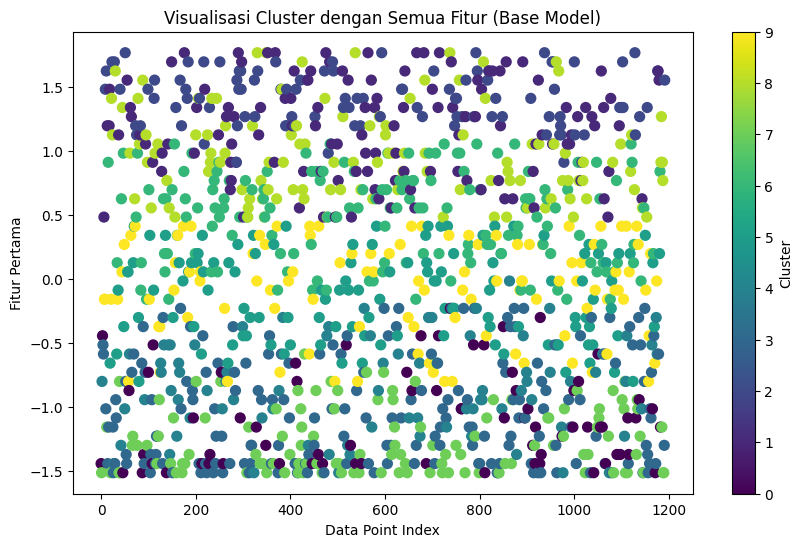

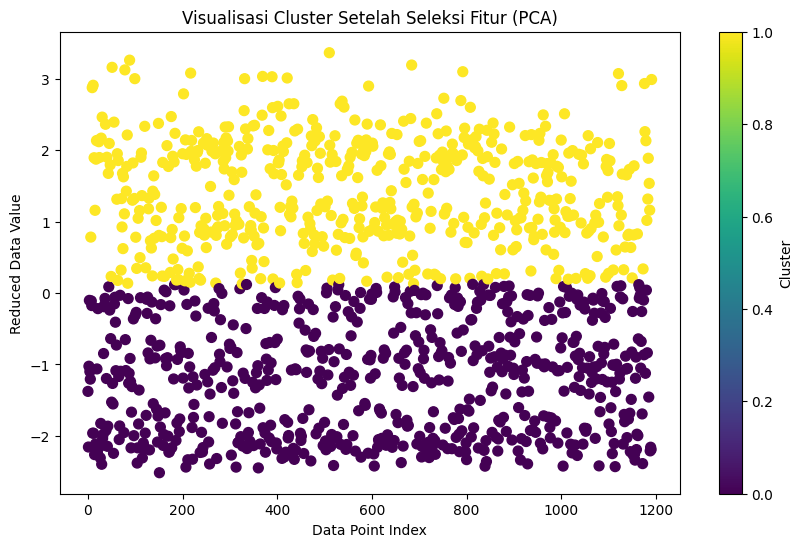

In [37]:
# Bandingkan distribusi cluster baru
# Visualisasi cluster dengan semua fitur (Base Model)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(clustering_data)), clustering_data.iloc[:, 0], c=cluster_labels, cmap='viridis', s=50)
plt.title(f'Visualisasi Cluster dengan Semua Fitur (Base Model)')
plt.colorbar(label='Cluster')
plt.xlabel('Data Point Index')
plt.ylabel('Fitur Pertama')
plt.show()

# Visualisasi cluster setelah seleksi fitur (PCA)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(reduced_data)), reduced_data[:, 0], c=cluster_labels_reduced, cmap='viridis', s=50)
plt.title(f'Visualisasi Cluster Setelah Seleksi Fitur (PCA)')
plt.colorbar(label='Cluster')
plt.xlabel('Data Point Index')
plt.ylabel('Reduced Data Value')
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [ ]:
# Type your code here

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?


Statistik Deskriptif untuk Tiap Cluster:
              age       bmi  children   charges  age_binned
Cluster                                                    
0       -0.797049 -0.219318 -0.061569 -0.532818    0.666154
1        0.920809  0.023042  0.056816  0.034049    3.197417


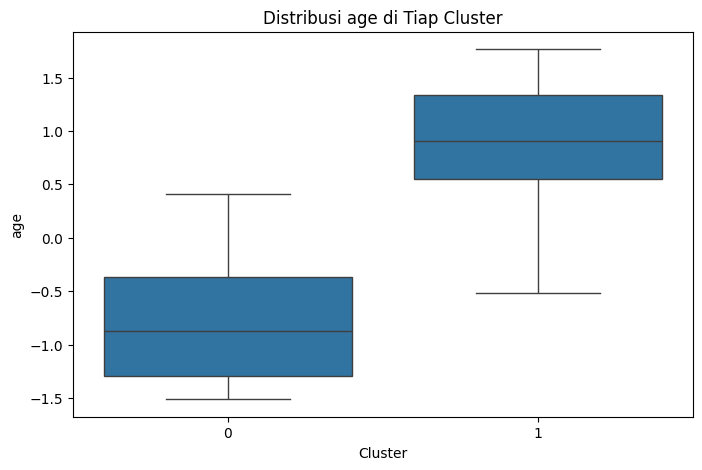

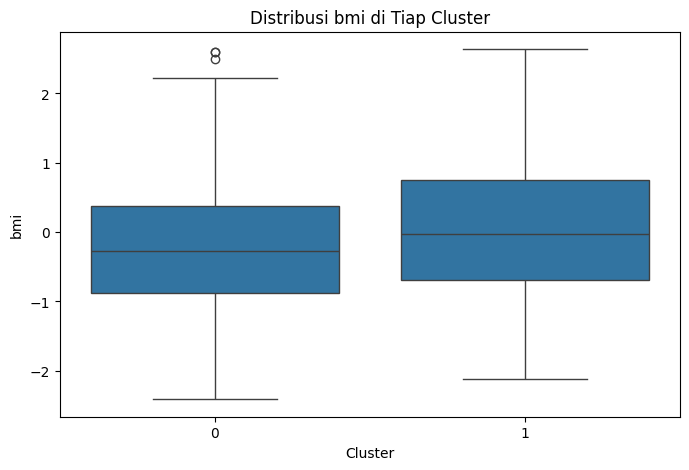

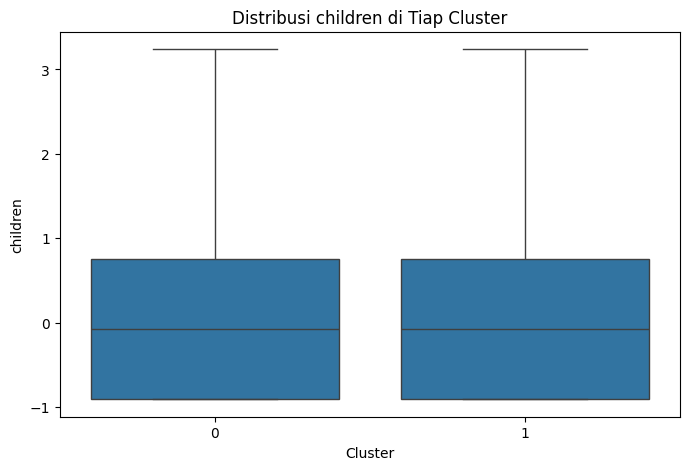

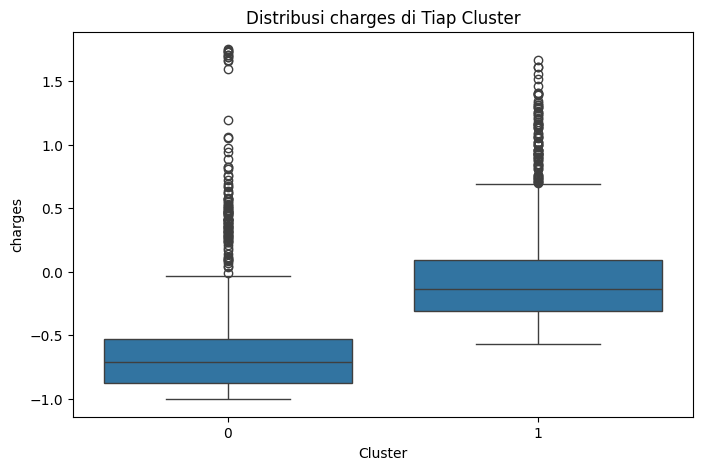

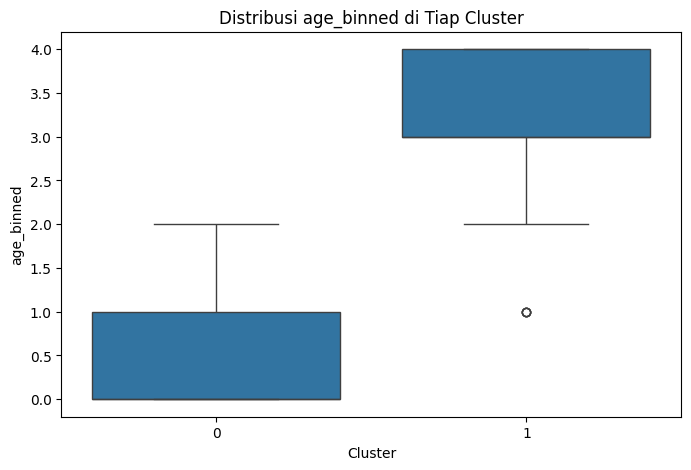

In [38]:
# Pilih hanya kolom numerikal untuk analisis statistik deskriptif
numerical_cols = test.select_dtypes(include=['float64', 'int64']).columns

# Analisis statistik deskriptif berdasarkan cluster
cluster_summary = test.groupby('Cluster')[numerical_cols].mean()

print("\nStatistik Deskriptif untuk Tiap Cluster:")
print(cluster_summary)

# Lihat distribusi data di setiap cluster untuk beberapa fitur utama
features_to_analyze = ['age', 'bmi', 'children', 'charges', 'age_binned']  # Ganti dengan fitur relevan
for feature in features_to_analyze:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Cluster', y=feature, data=test)
    plt.title(f'Distribusi {feature} di Tiap Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

Tulis hasil interpretasinya di sini.
1. Cluster 0:
  - Klasifikasi
    - age
      - Cluster 0: -0.797049 → Pelanggan dalam cluster ini lebih muda dari rata-rata.
    - bmi
      - Cluster 0: -0.219318 → Memiliki BMI lebih rendah dari rata-rata, menunjukkan bahwa pelanggan dalam cluster ini cenderung memiliki berat badan yang lebih ringan.
    - children
      - Cluster 0: -0.061569 → Sedikit lebih rendah dari rata-rata, menunjukkan bahwa pelanggan dalam cluster ini cenderung memiliki lebih sedikit anak.
    - charges
      - Cluster 0: -0.532818 → Lebih rendah dari rata-rata, berarti pelanggan dalam cluster ini membayar biaya yang lebih kecil untuk asuransi kesehatan.
    - age_binned
      - Cluster 0: 0.666154 → Masuk dalam kelompok usia lebih muda dibandingkan dengan keseluruhan dataset.
  - **Interpretasi:**
    - Cluster 0 cenderung lebih muda dibandingkan rata-rata populasi, yang terlihat dari nilai negatif pada variabel age. Mereka juga memiliki BMI yang lebih rendah, yang dapat mengindikasikan gaya hidup yang lebih sehat atau tingkat aktivitas fisik yang lebih tinggi. Selain itu, mereka cenderung memiliki jumlah anak yang lebih sedikit, kemungkinan karena mereka masih lajang, baru menikah, atau memiliki keluarga kecil. Dari sisi pengeluaran, biaya asuransi yang mereka bayarkan lebih rendah dari rata-rata, yang mungkin disebabkan oleh usia muda dan risiko kesehatan yang lebih rendah. Hal ini juga didukung oleh variabel age_binned, yang menunjukkan bahwa mereka termasuk dalam kelompok usia lebih muda.

2. Cluster 1:
  - Klasifikasi
    - age
      - Cluster 1: 0.920809 → Pelanggan dalam cluster ini lebih tua dari rata-rata.
    - bmi
      - Cluster 1: 0.023042 → Hampir sama dengan rata-rata, berarti distribusi BMI di cluster ini tidak jauh berbeda dari keseluruhan dataset.
    - children
      - Cluster 1: 0.056816 → Sedikit lebih tinggi dari rata-rata, menunjukkan bahwa pelanggan dalam cluster ini memiliki jumlah anak yang lebih banyak dibandingkan dengan rata-rata.
    - charges
      - Cluster 1: 0.034049 → Hampir sama dengan rata-rata, menunjukkan bahwa pengeluaran pelanggan dalam cluster ini untuk asuransi kesehatan mendekati nilai rata-rata dari seluruh dataset.
    - age_binned
      - Cluster 1: 3.197417 → Masuk dalam kelompok usia yang lebih tua, artinya mayoritas pelanggan dalam cluster ini termasuk dalam kategori usia lanjut.
  - **Interpretasi:**
    - Cluster 1 cenderung lebih tua dibandingkan rata-rata populasi, yang terlihat dari nilai positif pada variabel age. Mereka memiliki BMI yang sedikit lebih tinggi, meskipun perbedaannya tidak terlalu signifikan dibandingkan kelompok lainnya. Selain itu, mereka juga cenderung memiliki lebih banyak anak, yang menunjukkan bahwa mereka mungkin sudah berkeluarga atau berada dalam tahap kehidupan dengan tanggungan lebih besar. Dari sisi pengeluaran, biaya asuransi yang mereka bayarkan lebih tinggi dibandingkan rata-rata, kemungkinan karena faktor usia dan risiko kesehatan yang lebih besar. Hal ini juga didukung oleh variabel age_binned, yang menunjukkan bahwa mereka termasuk dalam kelompok usia yang lebih tua.

### **Kesimpulan Umum:**
- Cluster 0 terdiri dari individu yang lebih muda, memiliki BMI lebih rendah, dan jumlah anak yang lebih sedikit dibandingkan rata-rata. Mereka juga memiliki biaya asuransi yang lebih rendah, kemungkinan karena faktor usia yang masih muda dan risiko kesehatan yang lebih kecil.

- Cluster 1 mencakup individu yang lebih tua, dengan BMI sedikit lebih tinggi dan jumlah anak lebih banyak. Mereka juga memiliki biaya asuransi yang lebih tinggi, yang dapat dikaitkan dengan usia yang lebih lanjut dan meningkatnya risiko kesehatan.


# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [39]:
# Menambahkan kolom 'Cluster' ke DataFrame asli
test['Cluster'] = kmeans.labels_

# Mengekspor DataFrame ke dalam file CSV
test.to_csv('hasil_melakukan_clustering.csv', index=False)

print("Data berhasil disimpan dalam 'hasil_melakukan_clustering.csv'")

Data berhasil disimpan dalam 'hasil_melakukan_clustering.csv'
